# Venue ANOVA — Does scoring differ across MCG, Marvel Stadium and GMHBA Stadium?

**Hypothesis:** Mean total game score is the same across all three Melbourne-area venues.

**Method:** One-way ANOVA followed by Tukey HSD post-hoc test to identify which venue pairs differ.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set_theme(style='whitegrid', palette='muted')
DB = '../data/database/afl_analytics.db'
conn = sqlite3.connect(DB)

In [2]:
# Load total game scores for the three venues (home-and-away only, exclude finals)
df = pd.read_sql("""
    SELECT v.venue_name,
           mr.home_total_score + mr.away_total_score AS total_score,
           mr.home_total_score,
           mr.away_total_score,
           s.year
    FROM fact_match_results mr
    JOIN dim_venues  v ON mr.venue_key  = v.venue_key
    JOIN dim_seasons s ON mr.season_key = s.season_key
    WHERE v.venue_name IN ('MCG', 'Marvel Stadium', 'GMHBA Stadium')
      AND mr.is_final = 0
      AND mr.home_total_score IS NOT NULL
""", conn)

print(f'Total matches: {len(df)}')
print(df.groupby('venue_name')['total_score'].agg(['count','mean','std']).round(1))

Total matches: 1414
                count   mean   std
venue_name                        
GMHBA Stadium     123  160.1  46.5
MCG               648  160.8  46.6
Marvel Stadium    643  167.9  48.0


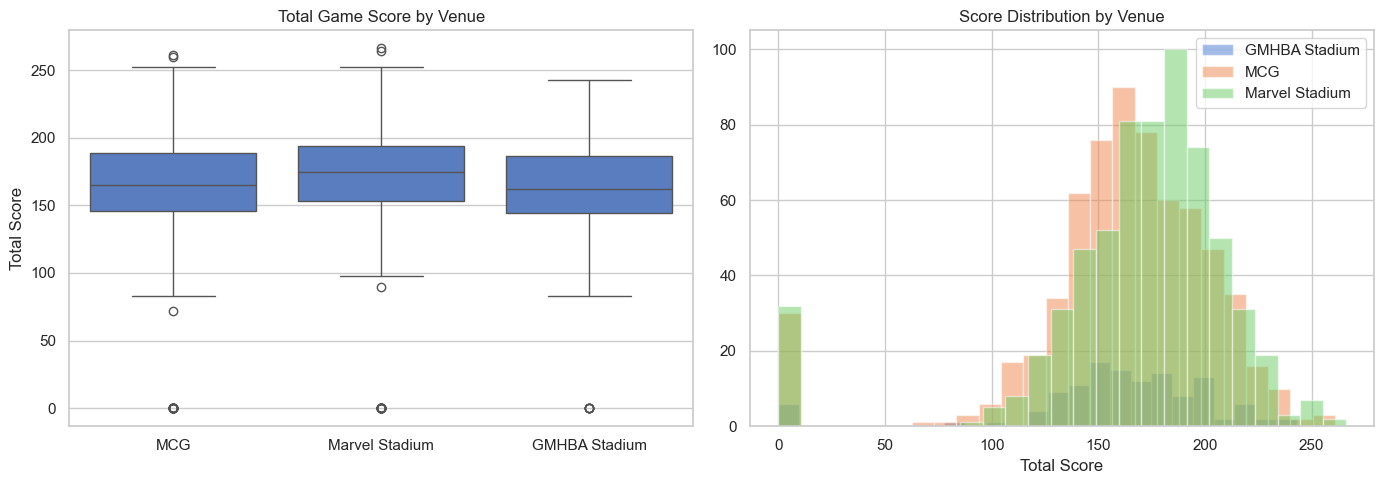

In [3]:
# Visualise distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='venue_name', y='total_score', ax=axes[0], order=['MCG','Marvel Stadium','GMHBA Stadium'])
axes[0].set_title('Total Game Score by Venue')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Score')

for venue, grp in df.groupby('venue_name'):
    axes[1].hist(grp['total_score'], alpha=0.5, bins=25, label=venue)
axes[1].set_title('Score Distribution by Venue')
axes[1].set_xlabel('Total Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# One-way ANOVA
mcg    = df[df.venue_name == 'MCG']['total_score']
marvel = df[df.venue_name == 'Marvel Stadium']['total_score']
gmhba  = df[df.venue_name == 'GMHBA Stadium']['total_score']

f_stat, p_value = stats.f_oneway(mcg, marvel, gmhba)
print(f'One-way ANOVA')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_value:.4f}')
print()
alpha = 0.05
if p_value < alpha:
    print(f'Result: REJECT H0 (p < {alpha}). At least one venue has a different mean score.')
else:
    print(f'Result: FAIL TO REJECT H0 (p >= {alpha}). No significant difference detected.')

One-way ANOVA
  F-statistic : 4.0249
  p-value     : 0.0181

Result: REJECT H0 (p < 0.05). At least one venue has a different mean score.


In [5]:
# Tukey HSD post-hoc test — which venue pairs drive the difference?
tukey = pairwise_tukeyhsd(endog=df['total_score'], groups=df['venue_name'], alpha=0.05)
print(tukey.summary())

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1        group2     meandiff p-adj   lower    upper  reject
--------------------------------------------------------------------
GMHBA Stadium            MCG   0.7489 0.9858 -10.1466 11.6445  False
GMHBA Stadium Marvel Stadium   7.7725 0.2161  -3.1298 18.6748  False
          MCG Marvel Stadium   7.0236 0.0208   0.8571   13.19   True
--------------------------------------------------------------------


In [6]:
# Normality check (ANOVA assumption)
print('Shapiro-Wilk normality test (sample of 200 per venue):')
for name, grp in df.groupby('venue_name'):
    sample = grp['total_score'].sample(min(200, len(grp)), random_state=42)
    stat, p = stats.shapiro(sample)
    print(f'  {name:<20} W={stat:.4f}  p={p:.4f}')

print()
print('Levene test for equal variances:')
lev_stat, lev_p = stats.levene(mcg, marvel, gmhba)
print(f'  statistic={lev_stat:.4f}  p={lev_p:.4f}')

Shapiro-Wilk normality test (sample of 200 per venue):
  GMHBA Stadium        W=0.8275  p=0.0000
  MCG                  W=0.8896  p=0.0000
  Marvel Stadium       W=0.7775  p=0.0000

Levene test for equal variances:
  statistic=0.0465  p=0.9546


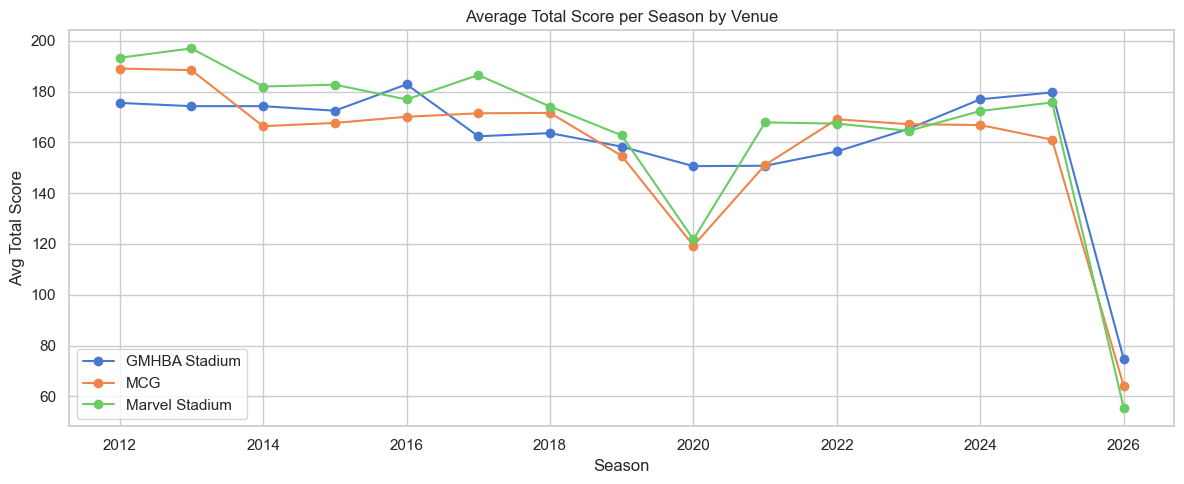

In [7]:
# Score trend at each venue over time
trend = df.groupby(['venue_name','year'])['total_score'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for venue, grp in trend.groupby('venue_name'):
    ax.plot(grp['year'], grp['total_score'], marker='o', label=venue)
ax.set_title('Average Total Score per Season by Venue')
ax.set_xlabel('Season')
ax.set_ylabel('Avg Total Score')
ax.legend()
plt.tight_layout()
plt.show()

conn.close()